# CODE PART 1 of 2 - Preprocessing for Shark Movement Forecasting: An Assessment for Ocean Recreational Safety

---
By: Isabella Parlato
Github Repository: https://github.com/ParlatoI/Shark-Forecasting_Capstone

From the Github repository in the "raw_datasets" folder, we'll be pulling in the following datasets into the colab content folder: "buoy_41009_clean" and "Regularized_tiger_shark_tracks"

In [1]:
# inital loading of libraries

import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
from datetime import datetime

# for preprocessing
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# for unsupervised methods
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist


In [2]:
# function for determining ideal split-ratio for train-test sets

import sys

## Check if packages are loaded; if not, import them
if 'numpy' not in sys.modules:
    import numpy as np
if 'pandas' not in sys.modules:
    import pandas as pd


def calcSplitRatio(df, p=None):
    """
    Calculate the ideal split ratio for training and testing sets.

    Parameters:
    p (int): The number of parameters (optional). If not provided, defaults to
    the number of columns minus 1 (assuming the last column is the target).

    df (DataFrame): The DataFrame that will be used for analysis.

    Returns:
    float: The training set proportion.
    """
    ## Set p to the number of predictors if not provided
    if p is None:
        p = df.shape[1] - 1  ## The number of features (predictors),
                             ## assuming last column is target

    ## Calculate ideal number for testing set
    test_N = (1 / np.sqrt(p)) * len(df)

    ## Calculate testing proportion
    test_prop = round(test_N / len(df), 2)

    ## Calculate training proportion
    train_prop = 1 - test_prop

    ## Print the results
    print(f"The ideal split ratio is {train_prop}:{test_prop} training:testing")

    ## Return the size of the training set proportion
    return train_prop


In [3]:
# load datasets

# URLs to raw GitHub files
buoy_url = "https://raw.githubusercontent.com/ParlatoI/Shark-Forecasting_Capstone/main/raw_datasets/buoy_41009_clean.csv"
sharks_url = "https://raw.githubusercontent.com/ParlatoI/Shark-Forecasting_Capstone/main/raw_datasets/Regularized_tiger_shark_tracks.csv"

# load buoy and shark tracking datasets
buoy = pd.read_csv(buoy_url)
sharks = pd.read_csv(sharks_url)

# Quick sanity check
print("Sharks dataset shape:", sharks.shape)
print("Buoy dataset shape:", buoy.shape)

sharks.head(), buoy.head()


Sharks dataset shape: (5227, 8)
Buoy dataset shape: (253464, 17)


(   Obs  Shark_ID        lon        lat  Month  Day  Year Season
 0    1     19687 -79.704199  26.402282     10   26  2018   Warm
 1    2     19687 -79.770902  26.312429     10   27  2018   Warm
 2    3     19687 -80.913401  24.700915     11    2  2018   Cold
 3    4     19687 -81.273479  24.612643     11    3  2018   Cold
 4    5     19802 -79.013915  26.748559      1   14  2019   Cold,
    year  month  day  hour  minute   WDIR  WSPD   GST  WVHT   DPD   APD  MWD  \
 0  2010      1    1    19      20  328.0  10.1  11.9  1.44  4.00  3.85  NaN   
 1  2010      1    1    19      50  320.0  12.1  14.1  1.60  5.00  4.31  NaN   
 2  2010      1    1    20      20  336.0  10.4  13.4  1.88  5.56  4.72  NaN   
 3  2010      1    1    20      50  318.0  13.3  16.2  2.08  5.56  4.90  NaN   
 4  2010      1    1    21      20  323.0  12.9  16.7  2.37  6.25  5.03  NaN   
 
      PRES  ATMP  WTMP  DEWP             datetime  
 0  1013.1  17.1  23.4  15.5  2010-01-01 19:20:00  
 1  1013.0  16.8  23.4 

In [4]:
# standardize col. names to lowercase & confirm column names
buoy.columns = buoy.columns.str.lower().str.strip()
sharks.columns = sharks.columns.str.lower().str.strip()

print("Buoy columns:", buoy.columns.tolist())
print("Shark columns:", sharks.columns.tolist())

Buoy columns: ['year', 'month', 'day', 'hour', 'minute', 'wdir', 'wspd', 'gst', 'wvht', 'dpd', 'apd', 'mwd', 'pres', 'atmp', 'wtmp', 'dewp', 'datetime']
Shark columns: ['obs', 'shark_id', 'lon', 'lat', 'month', 'day', 'year', 'season']


In [5]:
# create new clean datetime column
buoy["timestamp"] = pd.to_datetime(buoy["datetime"], errors="coerce")
## errors should handle with NaT (Not a Time) for missing

# create timestamp to add to month-day-year for shark datset since buoy dataset has times
sharks["timestamp"] = pd.to_datetime(
    sharks[["year", "month", "day"]].astype(str).agg("-".join, axis=1),
    format="%Y-%m-%d", ## in string, date as 4 digit year, 2 digit month, 2 digit day format
    errors="coerce"
)

# default time assigned is 12:00 for mid-day for shark dataset which lacks hourly times
sharks["timestamp"] = sharks["timestamp"] + pd.Timedelta("12:00:00")


Since this project isn't looking into time of days with variations, more weather by the day with shark presence, creating standard timestamp to allow merge between datasets. So need to keep in mind that this "mid-day" assumption is being made.

Merged dataset columns: ['obs', 'shark_id', 'lon', 'lat', 'month_x', 'day_x', 'year_x', 'season', 'timestamp', 'year_y', 'month_y', 'day_y', 'hour', 'minute', 'wdir', 'wspd', 'gst', 'wvht', 'dpd', 'apd', 'mwd', 'pres', 'atmp', 'wtmp', 'dewp', 'datetime']
Merged shape before filtering: (5227, 26)
Merged shape after filtering: (5182, 26)
1321   2012-08-05 12:00:00
1322   2012-08-06 12:00:00
1323   2012-08-07 12:00:00
1324   2012-08-08 12:00:00
1325   2012-08-09 12:00:00
Name: timestamp, dtype: datetime64[ns]
Total unmatched: 45


<Axes: xlabel='timestamp'>

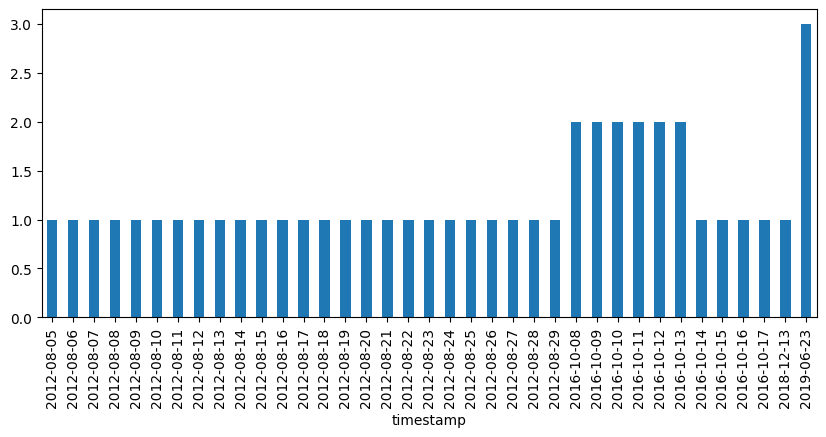

In [6]:
# merge shark detections with buoy conditions dataset on nearest timestamp

sharks = sharks.sort_values("timestamp")
buoy = buoy.sort_values("timestamp")

merged = pd.merge_asof(
    sharks,
    buoy,
    on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("24h") # daily date for full day window
)

print("Merged dataset columns:", merged.columns.tolist())
print("Merged shape before filtering:", merged.shape)

# Remove detections with no matching buoy record
merged = merged.dropna(subset=["wspd"])

print("Merged shape after filtering:", merged.shape)

unmatched_dates = sharks[~sharks["timestamp"].isin(merged["timestamp"])]["timestamp"]
print(unmatched_dates.head())
print("Total unmatched:", len(unmatched_dates))
unmatched_dates.dt.date.value_counts().sort_index().plot(kind="bar", figsize=(10,4))


I needed a way to connect the more irregular shark movement detections with regularly sampled environmental data so I did a daily tolerance for lining up nearest timestamps. Ultimately, decided to drop rows where no environmental buoy data connected since we need that context to be able to use them for modeling. It was an extremely small loss of only 45 rows.

August 5,2012 through August 29, 2012, October 8, 2016 through October 17, 2016, December 13, 2018, and June 23, 2019 - plot shows the groupings. Likely buoy outages or issues in collecting data until it was able to be fixed.

In [7]:
# create shark presence/absence response variable - binary
## using background samples

# Presence rows
merged["presence"] = 1

# Absence rows: every buoy timestamp, labeled 0
background = pd.DataFrame({"timestamp": buoy["timestamp"]})
background["presence"] = 0

absence_df = pd.merge_asof(
    background.sort_values("timestamp"),
    buoy.sort_values("timestamp"),
    on="timestamp",
    direction="nearest"
)

# Remove timestamps that coincide with shark presence
## would confuse the model if the sharks were both present and absent on same day
absence_df = absence_df[~absence_df["timestamp"].isin(merged["timestamp"])]

print("Presence timestamps:", len(merged["timestamp"].unique()))
print("Absence timestamps before filtering:", len(background))
print("Absence timestamps after filtering:", len(absence_df))


Presence timestamps: 2136
Absence timestamps before filtering: 253464
Absence timestamps after filtering: 252758


Since the tiger shark dataset only contains shark location detections, I needed some way to create "absence" data as well. So going to do so using the buoy's timeline/data samples for dates to create background absence variable. It was important to then clean the dataset of any rows that would be contradictory so absence rows should be times that the buoy took in environmental readings but sharks were not detected. It looks like 706 rows were removed that were contradictory.

It makes sense that absence rows initially had about high missingness for what would be missing Shark related data like shark ID, coordinates, shark day/month/year & season of detection. I don't want to lose coordinates of the sharks so for any absence columns, I'll just use the buoy's location


---


https://noaa-mirror.org/www.ndbc.noaa.gov/station_page.php@station=41009

Owned and maintained by National Data Buoy Center
3-meter discus buoy
SCOOP payload
28.508 N 80.185 W (28°30'27" N 80°11'6" W)

Site elevation: sea level
Air temp height: 3.4 m above site elevation
Anemometer height: 3.8 m above site elevation
Barometer elevation: 2.4 m above mean sea level
Sea temp depth: 2 m below water line
Water depth: 42 m
Watch circle radius: 115 yards



In [8]:
# add in buoy location: Latitude: 28.508° N, Longitude: -80.185° W to Absence Rows

buoy_lat = 28.508
buoy_lon = -80.185

absence_df["lat"] = buoy_lat
absence_df["lon"] = buoy_lon

# if leftover lat/lon-like columns exist, remove them
for col in ["lat_x","lat_y","latitude","lon_x","lon_y","longitude"]:
    if col in absence_df.columns:
        absence_df = absence_df.drop(columns=[col])
    if col in merged.columns:
        merged = merged.drop(columns=[col])

# combine into full dataset
full_df = pd.concat([merged, absence_df], ignore_index=True).sort_values("timestamp")
print("Full dataset shape:", full_df.shape)

Full dataset shape: (257940, 30)


In [9]:
# explore missingness

missing_summary = full_df.isnull().mean().sort_values(ascending=False)
missing_summary


,0
obs,0.979910
shark_id,0.979910
day_x,0.979910
month_x,0.979910
season,0.979910
year_x,0.979910
day_y,0.979910
month_y,0.979910
year_y,0.979910
mwd,0.770823


Reminder of results notes from EDA correlation heatmap for the buoy variables:

1. GST & WSPD are 0.99 - plan to drop one
2. Second highest at 0.89 correlation is DEWP & ATMP  - plan to drop one
3. followed by ATMP & WTMP at 0.82 - plan to drop one
4. WTMP & DEWP followed at 0.67 correlation
5. GST & WVHT at 0.66
6. WVHT & WSPD at 0.63\
7. DPD & APD at 0.62

In [10]:
# remove top 3 high correlation environmental variables

corr_pairs = [
    ("gst", "wspd"),     # 0.99 correlation
    ("dewp", "atmp"),    # 0.89 correlation
    ("atmp", "wtmp")     # 0.82 correlation
]

# the goal is to drop one of the correlated pair with more missingness than its partner variable
columns_to_drop_corr = []

for col1, col2 in corr_pairs:
    if col1 in full_df.columns and col2 in full_df.columns:
        miss1 = full_df[col1].isnull().mean()
        miss2 = full_df[col2].isnull().mean()

        if miss1 > miss2:
            drop_col = col1
        else:
            drop_col = col2

        columns_to_drop_corr.append(drop_col)
        print(f"Dropping '{drop_col}' due to high correlation between {col1} and {col2}.")
    else:
        print(f"Skipping pair ({col1}, {col2}) — one or both columns missing.")

full_df = full_df.drop(columns=columns_to_drop_corr)
print("\nDropped due to correlation:", columns_to_drop_corr)


Dropping 'gst' due to high correlation between gst and wspd.
Dropping 'dewp' due to high correlation between dewp and atmp.
Dropping 'wtmp' due to high correlation between atmp and wtmp.

Dropped due to correlation: ['gst', 'dewp', 'wtmp']


In [11]:
# now to drop shark only features that aren't needed

shark_only_cols = [
    "obs", "shark_id", "month_x", "day_x", "year_x", "season",
    "year_y", "month_y", "day_y"
]

full_df = full_df.drop(columns=[c for c in shark_only_cols if c in full_df.columns])

# Check missingness again
missing_summary = full_df.isnull().mean().sort_values(ascending=False)
missing_summary


,0
mwd,0.770823
dpd,0.594979
apd,0.594348
wvht,0.594348
year,0.020090
month,0.020090
day,0.020090
pres,0.017376
atmp,0.006215
wdir,0.003691


In running new missingness summary, there were 4 variables with missingness over about 50%:

1. mwd (mean wave direction) - about 77%
2. dpd (dominent wave period) - about 59%
3. wvht (wave height) - about 59%
4. apd (average wave period) - about 59%

everything else has way less missingness (about 2% or lower) so planning to drop these because otherwise I may need to impute them, which might add noise, and detract from the concrete actual environmental data

In [12]:
# drop variables with missingness over 50%

missing_summary = full_df.isnull().mean()
high_missing_cols = missing_summary[missing_summary > 0.50].index.tolist()

full_df = full_df.drop(columns=high_missing_cols)

print("Dropped for missingness:", high_missing_cols)


Dropped for missingness: ['wvht', 'dpd', 'apd', 'mwd']


In [13]:
# Save cleaned dataset as new csv

full_df.to_csv("cleaned_merged_shark_buoy.csv", index=False)


This is a good point to pull the dataset into a new csv since it's before any splitting for the models or model-type specific focused preprocessing.